<a href="https://colab.research.google.com/github/nouur-mohaamed/CreditCardDefault_ML_Project/blob/main/Credit_card_default_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [309]:
!pip install ucimlrepo

In [310]:
import pandas as pd
import numpy as np

In [311]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)


# Visualize the fetched data ( features and targets )

In [312]:
default_of_credit_card_clients.data

{'ids':           ID
 0          1
 1          2
 2          3
 3          4
 4          5
 ...      ...
 29995  29996
 29996  29997
 29997  29998
 29998  29999
 29999  30000
 
 [30000 rows x 1 columns],
 'features':            X1  X2  X3  X4  X5  X6  X7  X8  X9  X10  ...     X14    X15    X16  \
 0       20000   2   2   1  24   2   2  -1  -1   -2  ...     689      0      0   
 1      120000   2   2   2  26  -1   2   0   0    0  ...    2682   3272   3455   
 2       90000   2   2   2  34   0   0   0   0    0  ...   13559  14331  14948   
 3       50000   2   2   1  37   0   0   0   0    0  ...   49291  28314  28959   
 4       50000   1   2   1  57  -1   0  -1   0    0  ...   35835  20940  19146   
 ...       ...  ..  ..  ..  ..  ..  ..  ..  ..  ...  ...     ...    ...    ...   
 29995  220000   1   3   1  39   0   0   0   0    0  ...  208365  88004  31237   
 29996  150000   1   3   2  43  -1  -1  -1  -1    0  ...    3502   8979   5190   
 29997   30000   1   2   2  37   4   3   2  -1

In [313]:
features=default_of_credit_card_clients.data.features
features

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,...,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


In [314]:
targets=default_of_credit_card_clients.data.targets
targets

,Y
0,1
1,1
2,0
3,0
4,0
...,...
29995,0
29996,0
29997,1
29998,1


In [315]:
full_credit_card_data_table=pd.concat([features,targets],axis=1)
full_credit_card_data_table

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


# playing with pandas data frame

In [316]:
print(full_credit_card_data_table[['X1','X15']].head()) # get multiple columns (panda data frame 'subset')

       X1    X15
0   20000      0
1  120000   3272
2   90000  14331
3   50000  28314
4   50000  20940


In [317]:
print(full_credit_card_data_table[['X3']].head()) # get one column (pandas series)

   X3
0   2
1   2
2   2
3   2
4   2


In [318]:
full_credit_card_data_table.loc[[0,5,7]] # get rows 0, 5, 7

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
5,50000,1,1,2,37,0,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
7,100000,2,2,2,23,0,-1,-1,0,0,...,221,-159,567,380,601,0,581,1687,1542,0


In [319]:
full_credit_card_data_table.loc[[4]] # get row 4 as a data frame

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [320]:
full_credit_card_data_table.loc[4] # get row 4 as a series (where column names are indices)

,4
X1,50000
X2,1
X3,2
X4,1
X5,57
X6,-1
X7,0
X8,-1
X9,0
X10,0


In [321]:
full_credit_card_data_table.iloc[2:6,3] # get column of index 3 (column X4) from row 0f index 2 till row of index 5 (excluding row of index 6)

,X4
2,2
3,1
4,1
5,2


# understanding the data set

In [322]:
full_credit_card_data_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
 23  Y       300

In [323]:
full_credit_card_data_table.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


know the data types of features

In [324]:
full_credit_card_data_table.dtypes

,0
X1,int64
X2,int64
X3,int64
X4,int64
X5,int64
X6,int64
X7,int64
X8,int64
X9,int64
X10,int64


checking if any categorical values ( doesn't make sense )

In [325]:
full_credit_card_data_table['X2'].value_counts() # male-> 1 / female-> 2

,count
X2,
2,18112
1,11888


In [326]:
full_credit_card_data_table['X3'].value_counts() #Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).

,count
X3,
2,14030
1,10585
3,4917
5,280
4,123
6,51
0,14


In [327]:
full_credit_card_data_table['X4'].value_counts() #Marital status (1 = married; 2 = single; 3 = others).

,count
X4,
2,15964
1,13659
3,323
0,54


testing null values

In [328]:
full_credit_card_data_table.isnull().sum() # no null values

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
X9,0
X10,0


testing duplicate rows

In [329]:
full_credit_card_data_table.duplicated().sum() # we have 35 duplicate rows

np.int64(35)

testing the balance of data

In [330]:
full_credit_card_data_table['Y'].value_counts() # get the count of classes in a column

,count
Y,
0,23364
1,6636


In [331]:
not_default=full_credit_card_data_table['Y'].value_counts()[0]
default=full_credit_card_data_table['Y'].value_counts()[1]
print(f"the percentage of the not default: {round((not_default/(default+not_default))*100)}%")
print(f"the percentage of the default: {round((default/(default+not_default))*100)}%")

the percentage of the not default: 78%
the percentage of the default: 22%


<Axes: xlabel='Y'>

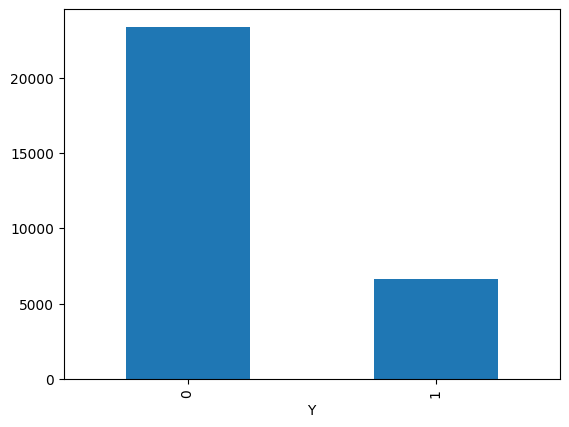

In [332]:
full_credit_card_data_table['Y'].value_counts().plot(kind='bar') # data is imbalanced

# DAY 1 REPORT
*   number of samples: 30,000
*   number of features: 23
*   Target : default? [ 1--> yes , 0--> no ]
*   missing values : no
*   Numerical features: Amount of the given credit,Age,Amount of bill statement,Amount of previous payment
*   Categorical features: Gender,Education,Marital status,History of past payment
* Class 0 percentage: 78%
* Class 1 percentage: 22%
### features meaning:
* Amount of the given credit [X1]: the credit limit given to that person (can't exceed)
* Amount of bill statement [X12-X17]: how much does he owe the bank at this month report
* Amount of previous payment[X18-X23]: how much of what he was owed did he pay at this month report
* History of past payment[X6 - X11]: what is his payment status at this month report ( was he delayed or not and by how many months was he delayed)






# preprocessing

remove the errored values and duplicate rows from data set

In [333]:
full_credit_card_data_table['X3'].replace([5,6,0],[4,4,4],inplace=True) # replace all the undocumented errored values with "other" category

/tmp/ipykernel_76688/3548722929.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_credit_card_data_table['X3'].replace([5,6,0],[4,4,4],inplace=True) # replace all the undocumented errored values with "other" category


In [334]:
full_credit_card_data_table['X4'].replace([0],[3],inplace=True)

/tmp/ipykernel_76688/678363165.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_credit_card_data_table['X4'].replace([0],[3],inplace=True)


In [335]:
full_credit_card_data_table.drop_duplicates(inplace=True)
full_credit_card_data_table.reset_index(drop=True, inplace=True)
# when dropping rows from a table never forget to reset the indices

## Feature engineering
obtain a more useful features by wrapping the existing ones in a relation creating new ones.

In [336]:
amount_of_bill_features=[f'X{i}' for i in range(12,18)]
full_credit_card_data_table[f'average_utilization']=full_credit_card_data_table[amount_of_bill_features].mean(axis=1)/full_credit_card_data_table['X1'].replace(0,1)

In [337]:
full_credit_card_data_table

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X16,X17,X18,X19,X20,X21,X22,X23,Y,average_utilization
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,689,0,0,0,0,1,0.064200
1,120000,2,2,2,26,-1,2,0,0,0,...,3455,3261,0,1000,1000,1000,0,2000,1,0.023718
2,90000,2,2,2,34,0,0,0,0,0,...,14948,15549,1518,1500,1000,1000,1000,5000,0,0.188246
3,50000,2,2,1,37,0,0,0,0,0,...,28959,29547,2000,2019,1200,1100,1069,1000,0,0.771113
4,50000,1,2,1,57,-1,0,-1,0,0,...,19146,19131,2000,36681,10000,9000,689,679,0,0.364463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29960,220000,1,3,1,39,0,0,0,0,0,...,31237,15980,8500,20000,5003,3047,5000,1000,0,0.549507
29961,150000,1,3,2,43,-1,-1,-1,-1,0,...,5190,0,1837,3526,8998,129,0,0,0,0.023536
29962,30000,1,2,2,37,4,3,2,-1,0,...,20582,19357,0,0,22000,4200,2000,3100,1,0.391644
29963,80000,1,3,1,41,1,-1,0,0,0,...,11855,48944,85900,3409,1178,1926,52964,1804,1,0.555440


In [338]:
previous_payment_features=[f'X{i}' for i in range(18,24)]
full_credit_card_data_table['previous_pay_rel_to_bill']=full_credit_card_data_table[previous_payment_features].mean(axis=1)/full_credit_card_data_table[amount_of_bill_features].mean(axis=1).replace(0,1)

In [339]:
full_credit_card_data_table

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X17,X18,X19,X20,X21,X22,X23,Y,average_utilization,previous_pay_rel_to_bill
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,689,0,0,0,0,1,0.064200,0.089434
1,120000,2,2,2,26,-1,2,0,0,0,...,3261,0,1000,1000,1000,0,2000,1,0.023718,0.292791
2,90000,2,2,2,34,0,0,0,0,0,...,15549,1518,1500,1000,1000,1000,5000,0,0.188246,0.108388
3,50000,2,2,1,37,0,0,0,0,0,...,29547,2000,2019,1200,1100,1069,1000,0,0.771113,0.036259
4,50000,1,2,1,57,-1,0,-1,0,0,...,19131,2000,36681,10000,9000,689,679,0,0.364463,0.540054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29960,220000,1,3,1,39,0,0,0,0,0,...,15980,8500,20000,5003,3047,5000,1000,0,0.549507,0.058661
29961,150000,1,3,2,43,-1,-1,-1,-1,0,...,0,1837,3526,8998,129,0,0,0,0.023536,0.684071
29962,30000,1,2,2,37,4,3,2,-1,0,...,19357,0,0,22000,4200,2000,3100,1,0.391644,0.443997
29963,80000,1,3,1,41,1,-1,0,0,0,...,48944,85900,3409,1178,1926,52964,1804,1,0.555440,0.552044


the feature engineering path didn't move the score higher or make a huge difference so it's futile to apply it
(i will keep it only for learning purpose nothing more)

create a modified copy of the data set with binary encoding

In [340]:
full_credit_card_data_table_encoded=full_credit_card_data_table.copy()

In [341]:
full_credit_card_data_table_encoded['X2']=full_credit_card_data_table_encoded['X2'].replace([1,2],[0,1]) # male-> 0 / female-> 1
full_credit_card_data_table_encoded

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X17,X18,X19,X20,X21,X22,X23,Y,average_utilization,previous_pay_rel_to_bill
0,20000,1,2,1,24,2,2,-1,-1,-2,...,0,0,689,0,0,0,0,1,0.064200,0.089434
1,120000,1,2,2,26,-1,2,0,0,0,...,3261,0,1000,1000,1000,0,2000,1,0.023718,0.292791
2,90000,1,2,2,34,0,0,0,0,0,...,15549,1518,1500,1000,1000,1000,5000,0,0.188246,0.108388
3,50000,1,2,1,37,0,0,0,0,0,...,29547,2000,2019,1200,1100,1069,1000,0,0.771113,0.036259
4,50000,0,2,1,57,-1,0,-1,0,0,...,19131,2000,36681,10000,9000,689,679,0,0.364463,0.540054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29960,220000,0,3,1,39,0,0,0,0,0,...,15980,8500,20000,5003,3047,5000,1000,0,0.549507,0.058661
29961,150000,0,3,2,43,-1,-1,-1,-1,0,...,0,1837,3526,8998,129,0,0,0,0.023536,0.684071
29962,30000,0,2,2,37,4,3,2,-1,0,...,19357,0,0,22000,4200,2000,3100,1,0.391644,0.443997
29963,80000,0,3,1,41,1,-1,0,0,0,...,48944,85900,3409,1178,1926,52964,1804,1,0.555440,0.552044


In [342]:
marital_status_data = []
for marital_status in full_credit_card_data_table_encoded['X4']:
  if marital_status==1:
    marital_status_data.append({
        'marital_status_msb':0,
        'marital_status_lsb':0
    })
  elif marital_status==2:
    marital_status_data.append({
        'marital_status_msb':0,
        'marital_status_lsb':1
    })
  else:
    marital_status_data.append({
        'marital_status_msb':1,
        'marital_status_lsb':0
    })
marital_status_df = pd.DataFrame(marital_status_data)
marital_status_df

,marital_status_msb,marital_status_lsb
0,0,0
1,0,1
2,0,1
3,0,0
4,0,0
...,...,...
29960,0,0
29961,0,1
29962,0,1
29963,0,0


In [343]:
table_target=full_credit_card_data_table_encoded['Y']
full_credit_card_data_table_encoded.drop(columns=['X4','Y'],inplace=True)
full_credit_card_data_table_encoded=pd.concat([full_credit_card_data_table_encoded,marital_status_df,table_target],axis=1)
full_credit_card_data_table_encoded

,X1,X2,X3,X5,X6,X7,X8,X9,X10,X11,...,X19,X20,X21,X22,X23,average_utilization,previous_pay_rel_to_bill,marital_status_msb,marital_status_lsb,Y
0,20000,1,2,24,2,2,-1,-1,-2,-2,...,689,0,0,0,0,0.064200,0.089434,0,0,1
1,120000,1,2,26,-1,2,0,0,0,2,...,1000,1000,1000,0,2000,0.023718,0.292791,0,1,1
2,90000,1,2,34,0,0,0,0,0,0,...,1500,1000,1000,1000,5000,0.188246,0.108388,0,1,0
3,50000,1,2,37,0,0,0,0,0,0,...,2019,1200,1100,1069,1000,0.771113,0.036259,0,0,0
4,50000,0,2,57,-1,0,-1,0,0,0,...,36681,10000,9000,689,679,0.364463,0.540054,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29960,220000,0,3,39,0,0,0,0,0,0,...,20000,5003,3047,5000,1000,0.549507,0.058661,0,0,0
29961,150000,0,3,43,-1,-1,-1,-1,0,0,...,3526,8998,129,0,0,0.023536,0.684071,0,1,0
29962,30000,0,2,37,4,3,2,-1,0,0,...,0,22000,4200,2000,3100,0.391644,0.443997,0,1,1
29963,80000,0,3,41,1,-1,0,0,0,-1,...,3409,1178,1926,52964,1804,0.555440,0.552044,0,0,1


# Train and Test Split ( not encoded )

In [344]:
from sklearn.model_selection import train_test_split

split train and test without solving the imbalance just yet, only considering that the same ratio between two classes is maintained both in train and test data using stratified

In [345]:
train,test=train_test_split(full_credit_card_data_table,test_size=0.2,random_state=42,stratify=full_credit_card_data_table['Y'])

make sure the same proportions is preserved (double checking step)

In [346]:
print(train['Y'].value_counts()/train.shape[0])
print(test['Y'].value_counts()/test.shape[0])

Y
0    0.778742
1    0.221258
Name: count, dtype: float64
Y
0    0.778742
1    0.221258
Name: count, dtype: float64


In [347]:
y_train=train['Y']
y_test=test['Y']
x_train=train.drop(columns=['Y'])
x_test=test.drop(columns=['Y'])

# Train and Test Split ( encoded )

In [348]:
train_encoded,test_encoded=train_test_split(full_credit_card_data_table_encoded,test_size=0.2,random_state=42,stratify=full_credit_card_data_table_encoded['Y'])

In [349]:
y_train_encoded=train_encoded['Y']
y_test_encoded=test_encoded['Y']
x_train_encoded=train_encoded.drop(columns=['Y'])
x_test_encoded=test_encoded.drop(columns=['Y'])

# scaling the numerical features only (not encoded)

* numerical features---> scaling
* categorical features---> encoding (if needed)

In [350]:
from sklearn.preprocessing import StandardScaler

In [351]:
num_features=['X1','X5','X12','X13','X14','X15','X16','X17','X18','X19','X20','X21','X22','X23','previous_pay_rel_to_bill','average_utilization']

In [352]:
scaler=StandardScaler()
x_train[num_features]=scaler.fit_transform(x_train[num_features])
x_test[num_features]=scaler.transform(x_test[num_features])

In [353]:
x_test

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X16,X17,X18,X19,X20,X21,X22,X23,average_utilization,previous_pay_rel_to_bill
8681,-0.903020,2,3,1,0.819644,0,0,0,0,0,...,-0.518437,-0.573376,-0.218945,-0.183578,-0.097357,-0.280841,-0.285432,-0.069508,0.095585,-0.018243
24179,0.560013,1,2,1,-0.485218,0,0,0,0,0,...,2.312826,2.441981,0.119655,0.081413,0.156719,0.112990,0.140199,0.095350,1.027802,-0.018490
27755,-0.595013,2,1,2,-1.137649,0,0,0,0,0,...,-0.471876,-0.516340,-0.248920,-0.183578,-0.210281,-0.187390,-0.218927,-0.234366,-0.787396,-0.017929
14938,-0.903020,2,2,2,-1.463864,0,0,2,0,0,...,-0.217548,-0.209404,-0.050544,-0.245685,-0.227219,-0.220765,-0.255970,-0.226563,0.542689,-0.018425
1486,0.483012,1,1,2,-0.376479,0,0,0,0,0,...,0.034887,0.077742,0.267852,0.582412,0.269642,0.012864,0.013840,-0.014555,-0.557271,-0.017703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9140,-0.749016,2,3,1,-0.050264,3,2,2,2,0,...,-0.206397,-0.181524,-0.338846,-0.133561,-0.294973,-0.253473,-0.251315,-0.179414,0.622265,-0.018553
20329,-0.826018,2,3,1,3.320628,0,0,2,2,4,...,0.350616,0.440119,-0.039094,-0.038661,-0.012665,0.012864,0.013840,-0.234366,1.602779,-0.018338
20048,-1.057023,2,1,2,0.819644,0,0,0,0,0,...,-0.163543,-0.652938,-0.239388,-0.179893,-0.207401,-0.245864,-0.318684,-0.289319,1.301392,-0.018499
154,-1.057023,2,3,2,-1.028910,0,0,0,0,0,...,-0.449592,-0.414487,-0.236930,-0.183578,-0.238511,-0.220765,-0.218927,-0.206890,0.041241,-0.018134


In [354]:
x_train

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X16,X17,X18,X19,X20,X21,X22,X23,average_utilization,previous_pay_rel_to_bill
27394,1.022024,1,2,1,-0.050264,-2,-2,-2,-2,-2,...,-0.665085,-0.652938,-0.338846,-0.245685,-0.294973,-0.320892,-0.318684,-0.289319,-1.062663,-0.018669
15341,-0.903020,2,3,3,0.167213,2,2,2,2,2,...,-0.220084,-0.208968,-0.200960,-0.183578,-0.294973,-0.093938,-0.318684,-0.223376,1.275829,-0.018522
26617,-0.672015,1,1,2,-1.355126,-1,-1,-1,-1,0,...,-0.650460,-0.645486,-0.312228,-0.227301,-0.244835,-0.291254,-0.318684,-0.232278,-1.041679,-0.014717
21600,-0.903020,2,2,2,-1.028910,-1,-1,-1,-1,-1,...,-0.665085,-0.639846,-0.214269,-0.229537,-0.272953,-0.320892,-0.266810,-0.289319,-1.024589,-0.014778
11563,0.252006,1,2,2,-0.593956,-2,-2,-2,-2,-2,...,1.513376,1.516122,0.877787,0.784923,6.772372,0.868346,1.428331,-0.050330,0.138043,-0.016814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14158,-1.211027,1,1,2,0.275951,0,0,-1,-1,-1,...,-0.665085,-0.639846,-0.278895,-0.229537,-0.272953,-0.320892,-0.266810,-0.289319,-0.281524,-0.018001
21745,-0.826018,2,2,2,-1.246387,-2,-2,-2,-2,-2,...,-0.657196,-0.191595,0.396745,-0.245685,-0.294973,-0.288918,1.509200,-0.289319,-0.701254,-0.014891
23917,-0.749016,1,2,2,-0.920172,2,2,2,2,2,...,-0.136367,-0.103355,-0.230935,-0.175297,-0.221573,-0.234116,-0.232228,-0.217880,0.199916,-0.018468
16667,-0.210004,1,2,2,-0.376479,1,2,2,2,2,...,0.574360,0.618664,-0.147005,-0.245685,0.072027,-0.053888,-0.185675,-0.124461,0.386106,-0.018481


# scaling the numerical features only (encoded)

In [355]:
x_train_encoded[num_features]=scaler.fit_transform(x_train_encoded[num_features])
x_test_encoded[num_features]=scaler.transform(x_test_encoded[num_features])

In [356]:
x_train_encoded

,X1,X2,X3,X5,X6,X7,X8,X9,X10,X11,...,X18,X19,X20,X21,X22,X23,average_utilization,previous_pay_rel_to_bill,marital_status_msb,marital_status_lsb
27394,1.022024,0,2,-0.050264,-2,-2,-2,-2,-2,-2,...,-0.338846,-0.245685,-0.294973,-0.320892,-0.318684,-0.289319,-1.062663,-0.018669,0,0
15341,-0.903020,1,3,0.167213,2,2,2,2,2,2,...,-0.200960,-0.183578,-0.294973,-0.093938,-0.318684,-0.223376,1.275829,-0.018522,1,0
26617,-0.672015,0,1,-1.355126,-1,-1,-1,-1,0,0,...,-0.312228,-0.227301,-0.244835,-0.291254,-0.318684,-0.232278,-1.041679,-0.014717,0,1
21600,-0.903020,1,2,-1.028910,-1,-1,-1,-1,-1,-1,...,-0.214269,-0.229537,-0.272953,-0.320892,-0.266810,-0.289319,-1.024589,-0.014778,0,1
11563,0.252006,0,2,-0.593956,-2,-2,-2,-2,-2,-2,...,0.877787,0.784923,6.772372,0.868346,1.428331,-0.050330,0.138043,-0.016814,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14158,-1.211027,0,1,0.275951,0,0,-1,-1,-1,-1,...,-0.278895,-0.229537,-0.272953,-0.320892,-0.266810,-0.289319,-0.281524,-0.018001,0,1
21745,-0.826018,1,2,-1.246387,-2,-2,-2,-2,-2,-2,...,0.396745,-0.245685,-0.294973,-0.288918,1.509200,-0.289319,-0.701254,-0.014891,0,1
23917,-0.749016,0,2,-0.920172,2,2,2,2,2,2,...,-0.230935,-0.175297,-0.221573,-0.234116,-0.232228,-0.217880,0.199916,-0.018468,0,1
16667,-0.210004,0,2,-0.376479,1,2,2,2,2,3,...,-0.147005,-0.245685,0.072027,-0.053888,-0.185675,-0.124461,0.386106,-0.018481,0,1


In [357]:
x_test_encoded

,X1,X2,X3,X5,X6,X7,X8,X9,X10,X11,...,X18,X19,X20,X21,X22,X23,average_utilization,previous_pay_rel_to_bill,marital_status_msb,marital_status_lsb
8681,-0.903020,1,3,0.819644,0,0,0,0,0,0,...,-0.218945,-0.183578,-0.097357,-0.280841,-0.285432,-0.069508,0.095585,-0.018243,0,0
24179,0.560013,0,2,-0.485218,0,0,0,0,0,0,...,0.119655,0.081413,0.156719,0.112990,0.140199,0.095350,1.027802,-0.018490,0,0
27755,-0.595013,1,1,-1.137649,0,0,0,0,0,0,...,-0.248920,-0.183578,-0.210281,-0.187390,-0.218927,-0.234366,-0.787396,-0.017929,0,1
14938,-0.903020,1,2,-1.463864,0,0,2,0,0,0,...,-0.050544,-0.245685,-0.227219,-0.220765,-0.255970,-0.226563,0.542689,-0.018425,0,1
1486,0.483012,0,1,-0.376479,0,0,0,0,0,0,...,0.267852,0.582412,0.269642,0.012864,0.013840,-0.014555,-0.557271,-0.017703,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9140,-0.749016,1,3,-0.050264,3,2,2,2,0,0,...,-0.338846,-0.133561,-0.294973,-0.253473,-0.251315,-0.179414,0.622265,-0.018553,0,0
20329,-0.826018,1,3,3.320628,0,0,2,2,4,4,...,-0.039094,-0.038661,-0.012665,0.012864,0.013840,-0.234366,1.602779,-0.018338,0,0
20048,-1.057023,1,1,0.819644,0,0,0,0,0,0,...,-0.239388,-0.179893,-0.207401,-0.245864,-0.318684,-0.289319,1.301392,-0.018499,0,1
154,-1.057023,1,3,-1.028910,0,0,0,0,0,0,...,-0.236930,-0.183578,-0.238511,-0.220765,-0.218927,-0.206890,0.041241,-0.018134,0,1


# LDA

In [358]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [359]:
LDA=LinearDiscriminantAnalysis()
LDA.fit(x_train,y_train)

LinearDiscriminantAnalysis()

In [360]:
prediction_lda=LDA.predict(x_test)

for encoded data

In [361]:
LDA_for_encoded=LinearDiscriminantAnalysis()
LDA_for_encoded.fit(x_train_encoded,y_train_encoded)

LinearDiscriminantAnalysis()

In [362]:
prediction_encoded_lda=LDA_for_encoded.predict(x_test_encoded)

# SVM

In [363]:
from sklearn.svm import SVC

In [364]:
SVM=SVC()
SVM.fit(x_train,y_train)

SVC()

In [365]:
prediction_svm=SVM.predict(x_test)

for encoded data

In [366]:
SVM_for_encoded=SVC()
SVM_for_encoded.fit(x_train_encoded,y_train_encoded)

SVC()

In [367]:
prediction_encoded_svm=SVM_for_encoded.predict(x_test_encoded)

# plotting

In [368]:
import matplotlib.pyplot as plt

# EVALUATION

In [369]:
from sklearn.metrics import (f1_score,precision_score,recall_score,classification_report,accuracy_score,confusion_matrix,ConfusionMatrixDisplay)

evaluation for LDA (not encoded)

In [370]:
accuracy_score(y_test,prediction_lda)

0.8114466878024362

In [371]:
precision_score(y_test,prediction_lda)

0.7

In [372]:
recall_score(y_test,prediction_lda)

0.25867269984917046

In [373]:
cm_lda=confusion_matrix(y_test,prediction_lda)

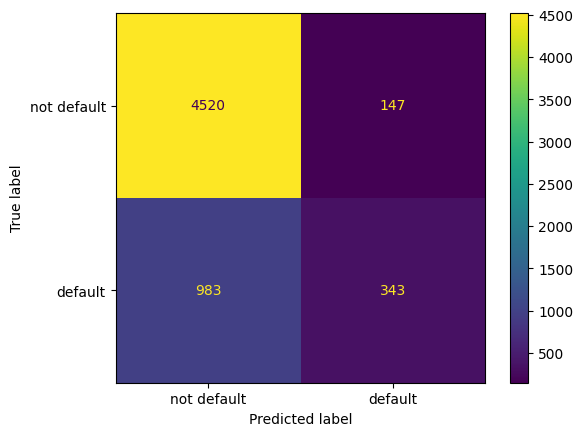

In [374]:
display=ConfusionMatrixDisplay(cm_lda,display_labels=['not default','default'])
display.plot()
plt.show()

In [375]:
print(classification_report(y_test,prediction_lda,target_names=['non default','default']))

              precision    recall  f1-score   support

 non default       0.82      0.97      0.89      4667
     default       0.70      0.26      0.38      1326

    accuracy                           0.81      5993
   macro avg       0.76      0.61      0.63      5993
weighted avg       0.79      0.81      0.78      5993



"LDA achieves 81% accuracy, but its recall for the default class is only 25%, meaning it detects only about one quarter of actual defaults. The model is strongly better at identifying non-default customers than default customers, likely reflecting the class imbalance."

for encoded

In [376]:
accuracy_score(y_test_encoded,prediction_encoded_lda)

0.81194727181712

In [377]:
print(classification_report(y_test_encoded,prediction_encoded_lda,target_names=['non default','default']))

              precision    recall  f1-score   support

 non default       0.82      0.97      0.89      4667
     default       0.70      0.26      0.38      1326

    accuracy                           0.81      5993
   macro avg       0.76      0.61      0.63      5993
weighted avg       0.80      0.81      0.78      5993



as you can see there's not much improvment when using the binary encoded data so we can safely stick to the label encoded data

evaluation for svm (not encoded)

In [378]:
accuracy_score(y_test,prediction_svm)

0.8167862506257301

In [379]:
precision_score(y_test,prediction_svm)

0.6711711711711712

In [380]:
recall_score(y_test,prediction_svm)

0.33710407239819007

In [381]:
cm_svm=confusion_matrix(y_test,prediction_svm)

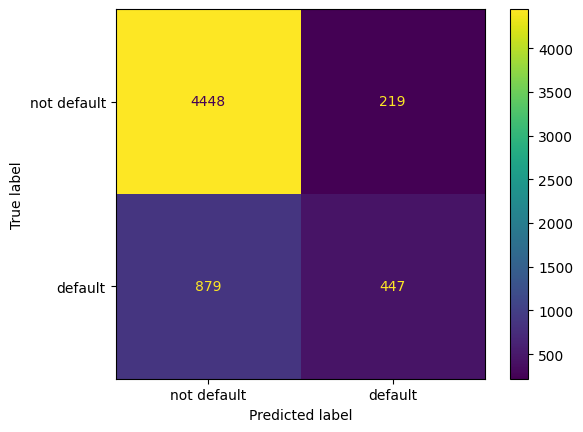

In [382]:
display=ConfusionMatrixDisplay(cm_svm,display_labels=['not default','default'])
display.plot()
plt.show()

In [383]:
print(classification_report(y_test,prediction_svm,target_names=['non default','default']))

              precision    recall  f1-score   support

 non default       0.83      0.95      0.89      4667
     default       0.67      0.34      0.45      1326

    accuracy                           0.82      5993
   macro avg       0.75      0.65      0.67      5993
weighted avg       0.80      0.82      0.79      5993



the same balance problem face the svm but it's better at recall (default) than the lda with a slight drop in percision

# BALANCING THE DATA

In [384]:
svm_balanced= SVC(class_weight='balanced')
svm_balanced.fit(x_train,y_train)

SVC(class_weight='balanced')

In [385]:
predicted_svm_balanced=svm_balanced.predict(x_test)

In [386]:
print(classification_report(y_test,predicted_svm_balanced,target_names=['non default','default']))

              precision    recall  f1-score   support

 non default       0.87      0.83      0.85      4667
     default       0.48      0.56      0.52      1326

    accuracy                           0.77      5993
   macro avg       0.67      0.69      0.68      5993
weighted avg       0.78      0.77      0.77      5993



# SMOTE

In [387]:
from imblearn.over_sampling import SMOTE

In [388]:
smote=SMOTE(random_state=42)
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)

In [389]:
y_train_smote.value_counts()

,count
Y,
0,18668
1,18668


In [398]:
svm_smote=SVC(C=0.01,gamma=0.01)

In [399]:
svm_smote.fit(x_train_smote,y_train_smote)

SVC(C=0.01, gamma=0.01)

In [400]:
predicted_svm_smote=svm_smote.predict(x_test)

In [401]:
print(classification_report(y_test,predicted_svm_smote,target_names=['non default','default']))

              precision    recall  f1-score   support

 non default       0.86      0.87      0.86      4667
     default       0.52      0.51      0.51      1326

    accuracy                           0.79      5993
   macro avg       0.69      0.69      0.69      5993
weighted avg       0.79      0.79      0.79      5993



In [402]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'class_weight': ['balanced'],
                         'gamma': ['scale', 0.01, 0.1]},
             scoring='f1', verbose=2)

In [403]:
print(grid_search.best_params_)   # which combination won
print(grid_search.best_score_)    # its cross-validated F1 score

best_svm = grid_search.best_estimator_
predicted_svm_tuned = best_svm.predict(x_test)
print(classification_report(y_test, predicted_svm_tuned, target_names=['non default','default']))

{'C': 1, 'class_weight': 'balanced', 'gamma': 'scale'}
0.5356172473475197
              precision    recall  f1-score   support

 non default       0.87      0.83      0.85      4667
     default       0.48      0.56      0.52      1326

    accuracy                           0.77      5993
   macro avg       0.67      0.69      0.68      5993
weighted avg       0.78      0.77      0.77      5993



In [404]:
LDA_balanced = LinearDiscriminantAnalysis(priors=[0.5, 0.5])
LDA_balanced.fit(x_train, y_train)
prediction_lda_balanced = LDA_balanced.predict(x_test)
print(classification_report(y_test, prediction_lda_balanced, target_names=['non default','default']))

              precision    recall  f1-score   support

 non default       0.86      0.77      0.81      4667
     default       0.41      0.58      0.48      1326

    accuracy                           0.72      5993
   macro avg       0.64      0.67      0.65      5993
weighted avg       0.76      0.72      0.74      5993



In [405]:
LDA_smote = LinearDiscriminantAnalysis()
LDA_smote.fit(x_train_smote, y_train_smote)
prediction_lda_smote = LDA_smote.predict(x_test)
print(classification_report(y_test, prediction_lda_smote, target_names=['non default','default']))

              precision    recall  f1-score   support

 non default       0.86      0.72      0.78      4667
     default       0.38      0.60      0.46      1326

    accuracy                           0.69      5993
   macro avg       0.62      0.66      0.62      5993
weighted avg       0.76      0.69      0.71      5993

